In [1]:
import numpy as np
from gpcam import GPOptimizer

import pandas as pd

import matplotlib.pyplot as plt


# Creating the function

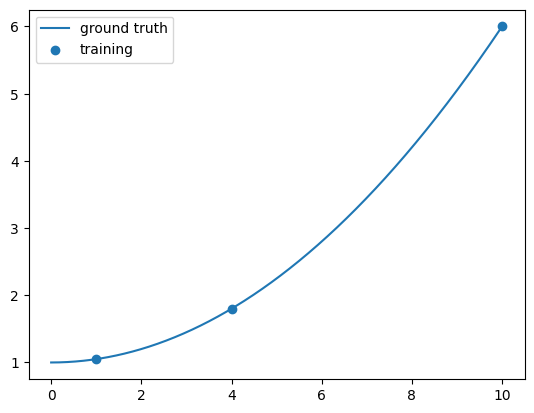

In [27]:
def my_y(x):
    return 0.05*x**2 + 1

x_train = np.array([1,4,10]).reshape(-1,1) # np.random.rand(3,1)
x_pred = np.linspace(0,10,1000).reshape(-1,1)

y_train = my_y(x_train).flatten()
y_test = my_y(x_pred).flatten()


plt.plot(x_pred,y_test,label="ground truth")
plt.scatter(x_train,y_train,label="training")
plt.legend()


In [ ]:
from gpcam.kernels import get_distance_matrix
from scipy.spatial.distance import cdist


def bump(d, r, beta, ampl):
    """
    Bump function for the kernel
    d: distances (can be any shape)
    r: radius parameter  
    ampl: amplitude
    """
    a = 1.0 - (d**2 / r**2)
    bump_values = np.zeros_like(a)
    
    # Only compute where a > 0
    positive_mask = a > 0.0
    if np.any(positive_mask):
        e = np.exp((-beta / a[positive_mask]) + beta)
        bump_values[positive_mask] = ampl * e
    
    return bump_values

    
# def bump_k(x1, x2, hps):

#     d1 = get_distance_matrix(x1,x_train)
#     d2 = get_distance_matrix(x2,x_train)
    
#     beta =1

#     # Compute bump functions
#     # gs1: bump function values for x1 locations
#     gs1 = bump(d1, hps[1], beta, 1.).T  # Shape: (n_train, len(x1))

#     # gs2: bump function values for x2 locations
#     gs2 = bump(d2, hps[1], beta, 1.).T  # Shape: (n_train, len(x2))

#     # Compute kernel matrix: K[i,j] = sum over training points
#     G = gs1.T @ gs2 
    
#     # Shape: (len(x1), len(x2))
    
#     # Scale by hyperparameters
#     kernel_matrix = 2.0 * hps[0] * G / float(len(x_train))
     
#     return kernel_matrix

def bump_k(x1, x2, hps):
    # Distance to each training point (using all dimensions)
    d1 = get_distance_matrix(x1, x_train)  # (n1, m) - can be geodesic!
    d2 = get_distance_matrix(x2, x_train)  # (n2, m)
    
    # Apply bump to create embedding
    phi_x1 = bump(d1, hps[1], beta=1, ampl=1.0)  # (n1, m)
    phi_x2 = bump(d2, hps[1], beta=1, ampl=1.0)  # (n2, m)
    
    # RBF on embeddings
    D_mat = cdist(phi_x1, phi_x2, metric='euclidean')
    
    my_kernel = hps[0] * np.exp(-D_mat**2 / hps[2])
    
    return my_kernel


def my_mean(x, hps):
    return np.ones(len(x)) * 0

def my_noise(x, hps):
    return np.ones(len(x)) * 1e-5

In [29]:
d1 = np.subtract.outer(x_train[:,0], x_train[:,0])
d2 = np.subtract.outer(x_train[:,0], x_train[:,0])
D_mat = cdist(d1, d2, metric='euclidean')
D_mat

array([[ 0.        ,  5.19615242, 15.58845727],
       [ 5.19615242,  0.        , 10.39230485],
       [15.58845727, 10.39230485,  0.        ]])

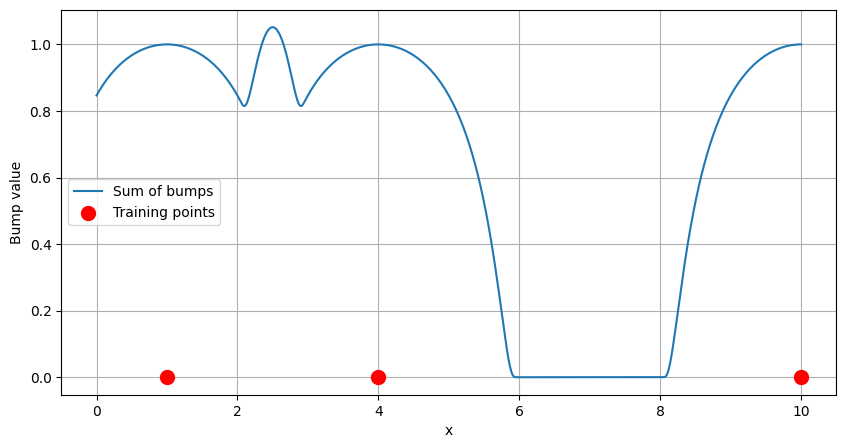

In [30]:
r = 2
beta = 0.5
ampl = 1

d = get_distance_matrix(x_pred,x_train)
my_bump_values = bump(d,r,beta,ampl)


# Plot the sum of bumps in x-space
plt.figure(figsize=(10, 5))

# Sum the bump contributions from all training points
total_bump = my_bump_values.sum(axis=1)  # Sum across the 3 training points

plt.plot(x_pred, total_bump, label='Sum of bumps')
plt.scatter(x_train, np.zeros_like(x_train), color='red', s=100, 
            label='Training points', zorder=5)
plt.xlabel('x')
plt.ylabel('Bump value')
plt.legend()
plt.grid(True)
plt.show()

In [31]:
# Step 4: Configure hyperparameters and initialize GPOptimizer

x_min = np.min(x_pred)
x_max = np.max(x_pred)
x_range = x_max - x_min

#Define hyperparameter bounds
bounds = np.empty((3, 2))
bounds[0] = np.array([1e-3, 50])      # sigma_f: signal variance      
bounds[1] = np.array([1e-5, 10])    # length_scale: bump radius
bounds[2] = np.array([0.5, 2])        #  beta

# bounds = np.empty((2, 2))
# bounds[0] = np.array([1e-3, 100])      # sigma_f: signal variance      
# bounds[1] = np.array([0.05*x_range , 0.5*x_range])    # length_scale: bump radius

# Initial hyperparameters (middle of bounds)
init_hps = np.mean(bounds, axis=1)
print(f"\nInitial hyperparameters: {init_hps}")

my_gpo = GPOptimizer(x_train, y_train,
                     init_hyperparameters=init_hps,
                     kernel_function=bump_k,
                     prior_mean_function=my_mean, 
                     noise_function=my_noise,
                        )

initial_log_likelihood = my_gpo.log_likelihood(init_hps)
print(f"Initial log likelihood: {initial_log_likelihood:.6f}")


# Step 5: Train the GP model

my_gpo.train(hyperparameter_bounds=bounds, init_hyperparameters=init_hps, method='mcmc', max_iter=4000)


# Get optimized hyperparameters
final_hps = my_gpo.get_hyperparameters()
final_ll = my_gpo.log_likelihood(final_hps)
print(f"Final hyperparameters:   {final_hps}")
print(f"Final log likelihood:    {final_ll:.2f}")



Initial hyperparameters: [25.0005    5.000005  1.25    ]
Initial log likelihood: -7.915996
Final hyperparameters:   [22.05418558  4.86948374  1.33493906]
Final log likelihood:    -7.84


In [32]:
bounds

array([[1.e-03, 5.e+01],
       [1.e-05, 1.e+01],
       [5.e-01, 2.e+00]])

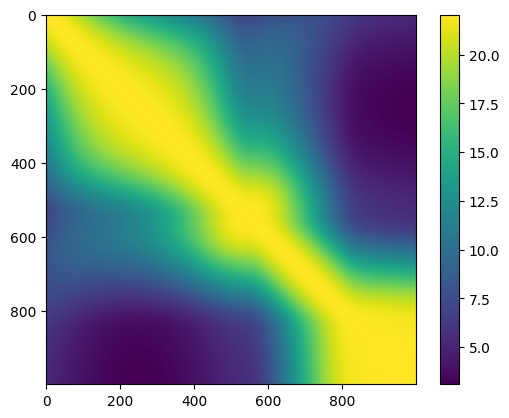

In [33]:
hps = final_hps
my_kernel = bump_k(x_pred,x_pred,hps)

plt.figure()
im = plt.imshow(my_kernel)
plt.colorbar(im)
plt.show()

Text(0, 0.5, 'y')

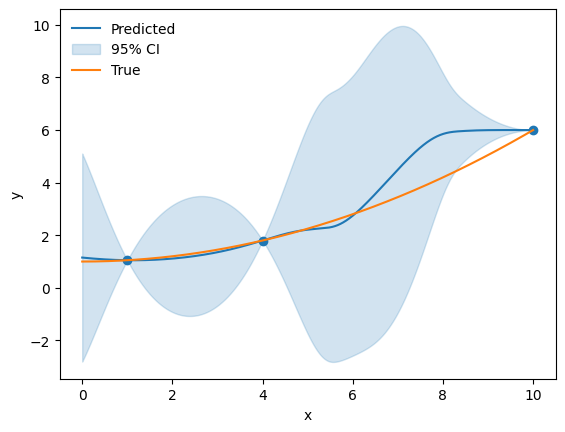

In [34]:
f = my_gpo.posterior_mean(x_pred)["m(x)"]
v = my_gpo.posterior_covariance(x_pred)["v(x)"]
v = np.sqrt(v)


plt.plot(x_pred,f,label="Predicted")
plt.fill_between(x_pred.flatten(), f-2*v, f+2*v, color='C0', alpha=0.2, label="95% CI")
plt.plot(x_pred,y_test,label="True")
plt.scatter(x_train,y_train)
plt.legend(frameon=False)
plt.xlabel("x")
plt.ylabel("y")

RMSE: 0.686142787817256


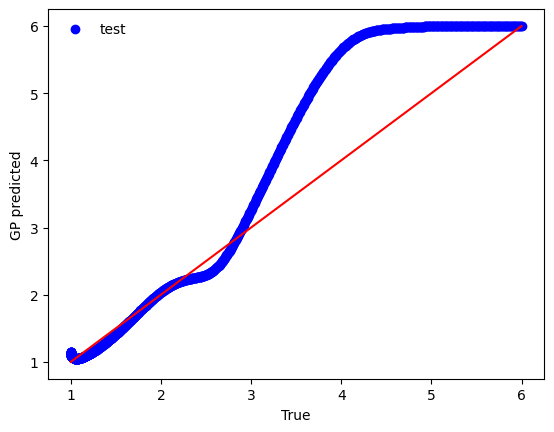

In [35]:

print('RMSE:', my_gpo.rmse(x_pred,y_test))

my_line = np.linspace(np.min(y_test),np.max(y_test),10)

#my_line = np.linspace(0,6,10)

plt.scatter(y_test,f,color="blue",label = 'test')
plt.plot(my_line,my_line,c="red")
plt.xlabel("True")
plt.ylabel("GP predicted")
plt.legend(frameon = False)
plt.show()

# Training with self-implemented codes 

In [10]:
my_noise(x_train,[1,1,1,1e-4])

array([0.0001, 0.0001, 0.0001, 0.0001])

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import cho_factor, cho_solve

# ============ Helper functions ============

def compute_prior_covariance_matrix(x, hyperparameters):
        """computes the covariance matrix from the kernel"""
        K = bump_kernel_geodesic(x, x, hyperparameters)
        return K

def calculate_V(x_data, hyperparameters):
        noise = my_noise(x_data, hyperparameters)
        return noise

def compute_mean(x, hyperparameters):
        """computes the covariance matrix from the kernel"""
        m = my_mean(x, hyperparameters)
        return m

def _addKV(K, V):
        assert np.ndim(K) == 2
        assert K.shape[0] == K.shape[1]

        if np.ndim(V) == 2:
                KV = K + V
                return KV
        else:
                KV = K.copy()
                np.fill_diagonal(KV, np.diag(K) + V)
        return KV

def calculate_Chol_factor(matrix, compute_device='cpu', args=None):
    """Compute Cholesky decomposition"""
    try:
        L, lower = cho_factor(matrix, lower=True)
        return L
    except np.linalg.LinAlgError:
        # Add jitter if matrix is not positive definite
        jitter = 1e-6
        L, lower = cho_factor(matrix + jitter * np.eye(len(matrix)), lower=True)
        return L

def calculate_Chol_solve(chol_factor, b, compute_device='cpu', args=None):
    """Solve using Cholesky factor"""
    return cho_solve((chol_factor, True), b)

def calculate_Chol_logdet(chol_factor, compute_device='cpu', args=None):
    """Compute log determinant from Cholesky factor"""
    return 2.0 * np.sum(np.log(np.diag(chol_factor)))

def my_noise(x, hyperparameters):
    """Noise variance (can be constant or position-dependent)"""
    # Simple constant noise
    noise_variance = hyperparameters[3]  # assuming hps[3] is noise parameter
    return np.full(len(x), noise_variance)

def my_mean(x, hyperparameters):
    """Mean function (can be constant or a function of x)"""
    # Simple constant mean
    return np.zeros(len(x))  # or hyperparameters[4] for constant mean


# ============ GP Class ============
 
class GP:
    def __init__(self, x_data, y_data):
        self.x_data = x_data
        self.y_data = y_data
        
        # Current values
        self.KVinvY = None
        self.KVlogdet = None
        self.K = None
        self.V = None
        self.m = None
        
        # History tracking
        self.training_history = {
            'hyperparameters': [],
            'log_likelihood': [],
            'data_fit': [],           # NEW: ((y - m).T @ KVinvY)
            'complexity_penalty': [], # NEW: KVlogdet
            'iteration': []
        }
        self.track_history = False
        self._iteration = 0
        
        # Placeholders
        self.compute_device = 'cpu'
        self.args = None
    
    def log_likelihood(self, hyperparameters):
        """
        Compute marginal log-likelihood and update internal state
        """
        # Compute everything
        K = compute_prior_covariance_matrix(self.x_data, hyperparameters)
        V = calculate_V(self.x_data, hyperparameters)
        m = compute_mean(self.x_data, hyperparameters)
        KVinvY, KVlogdet = self.compute_new_KVlogdet_KVinvY(K, V, m)
        
        # Update instance attributes
        self.K = K
        self.V = V
        self.m = m
        self.KVinvY = KVinvY
        self.KVlogdet = KVlogdet
        
        # Compute log likelihood components
        n = len(self.y_data)
        data_fit = (self.y_data - m).T @ KVinvY  # Data fit term
        complexity_penalty = KVlogdet              # Model complexity term
        constant = n * np.log(2.0 * np.pi)
        
        log_lik = -0.5 * (data_fit + complexity_penalty + constant)
        
        # Optional: track history
        if self.track_history:
            self.training_history['hyperparameters'].append(hyperparameters.copy())
            self.training_history['log_likelihood'].append(float(log_lik))
            self.training_history['data_fit'].append(float(data_fit))
            self.training_history['complexity_penalty'].append(float(complexity_penalty))
            self.training_history['iteration'].append(self._iteration)
            self._iteration += 1
        
        return float(log_lik)
    
    def compute_new_KVlogdet_KVinvY(self, K, V, m):
        """
        Recomputing KVinvY and logdet(KV) for new hyperparameters.
        """
        KV = _addKV(K, V)
        y_mean = self.y_data - m
        
        Chol_factor = calculate_Chol_factor(KV, compute_device=self.compute_device, args=self.args)
        KVinvY = calculate_Chol_solve(Chol_factor, y_mean, compute_device=self.compute_device, args=self.args)
        KVlogdet = calculate_Chol_logdet(Chol_factor, compute_device=self.compute_device, args=self.args)
        
        return KVinvY.reshape(len(y_mean)), KVlogdet
    
    def train(self, initial_hyperparameters, track_history=False, method='L-BFGS-B'):
        """Train the GP by optimizing hyperparameters"""
        from scipy.optimize import minimize
        
        self.track_history = track_history
        self._iteration = 0
        
        # Optimize (minimize negative log likelihood)
        result = minimize(
            lambda hps: -self.log_likelihood(hps),
            initial_hyperparameters,
            method=method,
            bounds=[(1e-6, None)] * len(initial_hyperparameters)
        )
        
        self.optimized_hyperparameters = result.x
        
        # Final evaluation with optimal hyperparameters
        self.log_likelihood(result.x)
        
        return result
    
    def plot_training_history(self):
        """Plot the training history"""
        history = self.training_history
        
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        
        # Log likelihood
        axes[0].plot(history['iteration'], history['log_likelihood'], 'b-', linewidth=2)
        axes[0].set_xlabel('Iteration')
        axes[0].set_ylabel('Log Likelihood')
        axes[0].set_title('Log Likelihood (total)')
        axes[0].grid(True, alpha=0.3)
        
        # Data fit term
        axes[1].plot(history['iteration'], history['data_fit'], 'r-', linewidth=2)
        axes[1].set_xlabel('Iteration')
        axes[1].set_ylabel('Data Fit Term')
        axes[1].set_title('$(y - m)^T K_V^{-1} (y - m)$')
        axes[1].grid(True, alpha=0.3)
        
        # Complexity penalty
        axes[2].plot(history['iteration'], history['complexity_penalty'], 'g-', linewidth=2)
        axes[2].set_xlabel('Iteration')
        axes[2].set_ylabel('Complexity Penalty')
        axes[2].set_title('$\log|K_V|$')
        axes[2].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

Optimized hyperparameters: [ 3.77590296  2.         10.          5.65180344]
Final log likelihood: -9.71619849791496
Final data fit term: 4.0001
Final complexity penalty: 8.0808


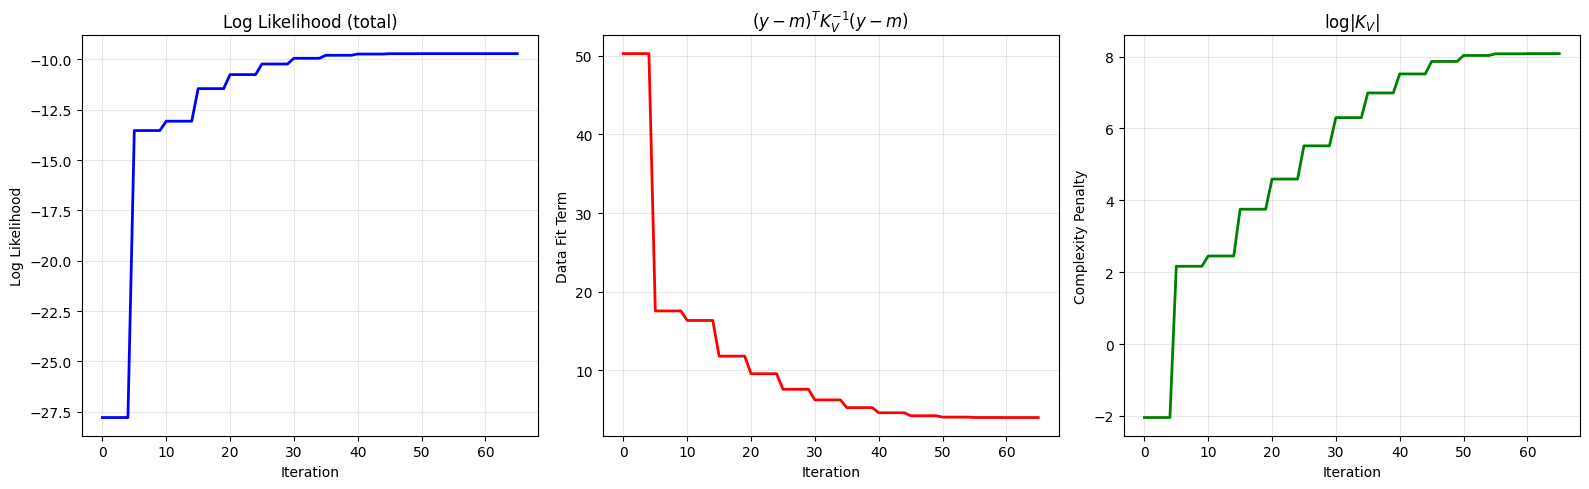

In [5]:
# Train
gp = GP(x_train, y_train)
initial_hps = np.array([1.0, 2.0, 10.0, 0.1])
result = gp.train(initial_hps, track_history=True)

print("Optimized hyperparameters:", result.x)
print("Final log likelihood:", -result.fun)
print(f"Final data fit term: {gp.training_history['data_fit'][-1]:.4f}")
print(f"Final complexity penalty: {gp.training_history['complexity_penalty'][-1]:.4f}")

# Plot
gp.plot_training_history()